# RSA Listener Fitting
**listener_logit / listener_choice → pRRSAc / pRRSAf 파라미터 추정**

| 모델 | 데이터 | 스케일 | RSA | Likelihood |
|------|--------|--------|-----|------------|
| A | listener_logit  | log P_LLM(s\|u,r) | pRRSAc | Normal(log P_L1 + c, σ) |
| B | listener_logit  | log P_LLM(s\|u,r) | pRRSAf | Normal(log P_L1 + c, σ) |
| C | listener_choice | count(s\|u,r)     | pRRSAc | Multinomial(P_L1) |
| D | listener_choice | count(s\|u,r)     | pRRSAf | Multinomial(P_L1) |

$$P_{L1}(s \mid u,r) \propto P(s) \cdot P_{S1}(u \mid s,r)$$
$$U_{\text{pRRSAc}}(u,s,r) = \phi_r\,U_{\text{epi}}(u,s) + (1-\phi_r)\cdot\alpha\cdot U_{\text{soc\_base}}(u)$$
$$U_{\text{pRRSAf}}(u,s,r) = \phi\,U_{\text{epi}}(u,s) + \alpha_r\cdot(1-\phi)\cdot U_{\text{soc\_base}}(u)$$

In [4]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pymc as pm
import pytensor.tensor as pt
import arviz as az
from pathlib import Path

from variables import ADJECTIVES, RELATIONSHIP_VAR, STATE_VAR

WARNING (pytensor.tensor.blas): Using NumPy C-API based implementation for BLAS functions.


In [5]:
# ── CONFIG ──────────────────────── (여기만 수정)
MODEL       = "qwen3_zero"   # "llama3" | "qwen3"
MCMC_DRAWS  = 2000
MCMC_TUNE   = 1000
MCMC_CHAINS = 4
# ────────────────────────────────────────────────

UTTERANCES = ADJECTIVES
STATES     = STATE_VAR
RELATIONS  = RELATIONSHIP_VAR
N_utt = len(UTTERANCES)
N_sta = len(STATES)
N_rel = len(RELATIONS)
print(f"model={MODEL}")

model=qwen3_zero


---
## Step 1 — Semantics & L0
$$P_{L_0}(s \mid u) \propto [\![u]\!](s) \cdot P(s)$$

In [6]:
#                  s=1   s=2   s=3   s=4   s=5
SEM = np.array([
    [0.00, 0.03, 0.06, 0.16, 1.00],   # großartig
    [0.03, 0.03, 0.66, 1.00, 0.90],   # gut
    [0.06, 0.47, 1.00, 0.66, 0.47],   # okay
    [0.91, 0.59, 0.06, 0.00, 0.00],   # schlecht
    [0.84, 0.25, 0.00, 0.00, 0.00],   # schrecklich
], dtype=float)

SEM = np.maximum(SEM, 0.01)
prior_s = np.ones(N_sta) / N_sta
L0 = SEM * prior_s[np.newaxis, :]
L0 = L0 / L0.sum(axis=1, keepdims=True)

print("L0 — P_L0(s | u):")
pd.DataFrame(L0, index=UTTERANCES, columns=[f"s={s}" for s in STATES]).round(3)

L0 — P_L0(s | u):


,s=1,s=2,s=3,s=4,s=5
großartig,0.008,0.024,0.048,0.127,0.794
gut,0.011,0.011,0.252,0.382,0.344
okay,0.023,0.177,0.376,0.248,0.177
schlecht,0.576,0.373,0.038,0.006,0.006
schrecklich,0.750,0.223,0.009,0.009,0.009


## Step 2 — Utilities

We first define a **value function** that assigns a desirability score to each state:

$$V(s) = \alpha \cdot s$$

where $\alpha \geq 0$ scales how strongly higher states are preferred. The speaker then weighs two competing utilities for each utterance.

**Epistemic utility** — how well the utterance conveys the intended state $s$ (depends on $s$):

$$U_{\text{epi}}(u, s) = \log P_{L_0}(s \mid u)$$

**Social utility base** — the expected state value the listener infers from $u$, computed without $\alpha$ (depends only on $u$, not on the intended $s$):

$$U_{\text{soc\_base}}(u) = \sum_{s'} P_{L_0}(s' \mid u) \cdot s'$$

The full social utility $U_{\text{soc}}(u) = \alpha \cdot U_{\text{soc\_base}}(u)$ is formed by multiplying $\alpha$ inside the MCMC stage, so we precompute only $U_{\text{soc\_base}}$ here.

The two models differ in **which parameters vary by relationship**:

- **pRRSAc**: $\phi_r$ is relationship-specific; $\alpha$ is a single global scale.  
  $U(u,s,r) = \phi_r \cdot U_{\text{epi}}(u,s) + (1-\phi_r)\cdot\alpha\cdot U_{\text{soc\_base}}(u)$

- **pRRSAf**: $\alpha_r$ is relationship-specific; $\phi$ is a single global weight.  
  $U(u,s,r) = \phi \cdot U_{\text{epi}}(u,s) + \alpha_r\cdot(1-\phi)\cdot U_{\text{soc\_base}}(u)$

Both $\alpha$ (or $\alpha_r$) and $\phi$ (or $\phi_r$) are inferred in the MCMC stage.

In [16]:
state_vals = np.array(STATES, dtype=float)

U_epi = np.log(L0 + 1e-10)                        # (N_utt, N_sta)
# α를 곱하지 않은 "base" U_soc — α는 나중에 MCMC에서 곱함
U_soc_base = (L0 * state_vals[np.newaxis, :]).sum(1)   # (N_utt,)
# U_soc(u) = α * U_soc_base(u)  ← α는 PyMC 안에서 곱해짐

print("U_epi:")
print(pd.DataFrame(U_epi, index=UTTERANCES, columns=[f"s={s}" for s in STATES]).round(3).to_string())
print("\nU_soc_base: (α=1 for now, alpha will be multiplied afterwards)")
for u, v in zip(UTTERANCES, U_soc_base):
    print(f"  {u:12s}: {v:.3f}  {'█'*int(v*5)}")

U_epi:
               s=1    s=2    s=3    s=4    s=5
großartig   -4.836 -3.738 -3.045 -2.064 -0.231
gut         -4.470 -4.470 -1.379 -0.963 -1.069
okay        -3.792 -1.733 -0.978 -1.394 -1.733
schlecht    -0.552 -0.985 -3.271 -5.063 -5.063
schrecklich -0.288 -1.500 -4.718 -4.718 -4.718

U_soc_base: (α=1 for now, alpha will be multiplied afterwards)
  großartig   : 4.675  ███████████████████████
  gut         : 4.034  ████████████████████
  okay        : 3.380  ████████████████
  schlecht    : 1.494  ███████
  schrecklich : 1.304  ██████


---
## Step 3 — Data Loading

In [17]:
def _parse_state(text):
    m = re.search(r'[1-5]', str(text))
    return int(m.group()) if m else None


def flat_listener_logit(model):
    """
    각 CSV 행(situation × rep) × 5상태 = 독립 관측치
    logprob_: 5개 후보 내 renormalized log-prob = log P_LLM(s|u,r) 스케일
    반환: (rel_idx, utt_idx, sta_idx, obs)
    """
    p = Path(f'results/listener_logit_{model}.csv')
    if not p.exists():
        print(f'[없음] {p}'); return None
    df = pd.read_csv(p)
    rows = []
    for _, row in df.iterrows():
        try:
            r_i = RELATIONS.index(row['relationship'])
            u_i = UTTERANCES.index(row['adjective'])
        except ValueError:
            continue
        for s_i, sta in enumerate(STATES):
            col = f'logprob_{sta}'
            if col not in df.columns: continue
            rows.append({'rel_idx': r_i, 'utt_idx': u_i,
                         'sta_idx': s_i, 'obs': float(row[col])})
    df_f = pd.DataFrame(rows)
    n_cond = N_rel * N_utt * N_sta
    print(f'flat_listener_logit_{model}: {len(df_f)} obs '
          f'({len(df_f)//n_cond} per condition)')
    return (df_f['rel_idx'].values.astype(int),
            df_f['utt_idx'].values.astype(int),
            df_f['sta_idx'].values.astype(int),
            df_f['obs'].values)


def load_listener_counts(model):
    """counts_listener[r, u, s] — situation+rep 합산"""
    p = Path(f'results/listener_choice_{model}.csv')
    if not p.exists(): return print(f'[없음] {p}')
    df = pd.read_csv(p)
    df['inferred'] = df['response_text'].apply(_parse_state)
    n_fail = df['inferred'].isna().sum()
    print(f'파싱 실패: {n_fail}/{len(df)} ({100*n_fail/len(df):.1f}%)')
    df = df.dropna(subset=['inferred'])
    df['inferred'] = df['inferred'].astype(int)
    out = np.zeros((N_rel, N_utt, N_sta))
    for r_i, rel in enumerate(RELATIONS):
        for u_i, adj in enumerate(UTTERANCES):
            mask = (df['relationship'] == rel) & (df['adjective'] == adj)
            for s_i, sta in enumerate(STATES):
                out[r_i, u_i, s_i] = (df.loc[mask, 'inferred'] == sta).sum()
    print(f'listener_counts_{model}: {out.shape}, total={out.sum():.0f}')
    return out

In [18]:

flat_li         = flat_listener_logit(MODEL)    # (rel,utt,sta,obs) | None
counts_listener = load_listener_counts(MODEL)   # (N_rel,N_utt,N_sta) | None

flat_listener_logit_qwen3_zero: 500 obs (5 per condition)
파싱 실패: 0/1000 (0.0%)
listener_counts_qwen3_zero: (4, 5, 5), total=1000


---
## Step 4 — PyMC Forward Models

```
build_rsa_c → pRRSAc: U = φ_r·U_epi + (1-φ_r)·α·U_soc_base
build_rsa_f → pRRSAf: U = φ·U_epi + α_r·(1-φ)·U_soc_base
→ log_L1[r, u, s] = log P_L1(s | u, r)  (state 축 정규화)
```

In [19]:
def build_rsa_c(phi, alpha, lam):
    """pRRSAc → log_S1, log_L1: (N_rel, N_utt, N_sta)
    U = φ_r·U_epi + (1-φ_r)·α·U_soc_base
    φ: (N_rel,)  — 관계별 epistemic weight
    α: scalar    — 전역 social utility scale
    """
    U_epi_t      = pt.as_tensor_variable(U_epi)        # (N_utt, N_sta)
    U_soc_base_t = pt.as_tensor_variable(U_soc_base)   # (N_utt,)
    phi_b = phi[:, None, None]                          # (N_rel, 1, 1)
    U = phi_b * U_epi_t[None, :, :] + (1 - phi_b) * alpha * U_soc_base_t[None, :, None]
    logits = lam * U
    log_S1 = logits - pt.logsumexp(logits, axis=1, keepdims=True)
    log_L1 = log_S1  - pt.logsumexp(log_S1,  axis=2, keepdims=True)
    return log_S1, log_L1


def build_rsa_f(alpha, phi, lam):
    """pRRSAf → log_S1, log_L1: (N_rel, N_utt, N_sta)
    U = φ·U_epi + α_r·(1-φ)·U_soc_base
    α: (N_rel,)  — 관계별 social utility scale
    φ: scalar    — 전역 epistemic weight
    """
    U_epi_t      = pt.as_tensor_variable(U_epi)        # (N_utt, N_sta)
    U_soc_base_t = pt.as_tensor_variable(U_soc_base)   # (N_utt,)
    alpha_b = alpha[:, None, None]                      # (N_rel, 1, 1)
    U = phi * U_epi_t[None, :, :] + alpha_b * (1 - phi) * U_soc_base_t[None, :, None]
    logits = lam * U
    log_S1 = logits - pt.logsumexp(logits, axis=1, keepdims=True)
    log_L1 = log_S1  - pt.logsumexp(log_S1,  axis=2, keepdims=True)
    return log_S1, log_L1


print('build_rsa_c / build_rsa_f 정의 완료')

build_rsa_c / build_rsa_f 정의 완료


---
## Step 5 — Sanity Check

listener_logit_avg_qwen3_zero: (4, 5, 5)  ※ sanity/PPC 전용


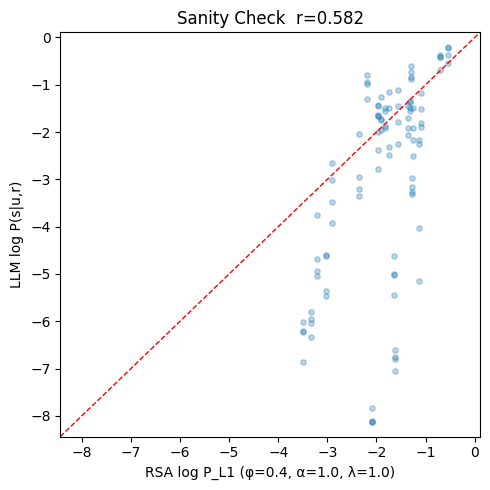

In [22]:
def load_listener_logit_avg(model):
    """[sanity/PPC 전용] situation 평균 logprobs_listener[r, u, s]"""
    p = Path(f'results/listener_logit_{model}.csv')
    if not p.exists(): return print(f'[없음] {p}')
    df = pd.read_csv(p)
    out = np.zeros((N_rel, N_utt, N_sta))
    for r_i, rel in enumerate(RELATIONS):
        for u_i, adj in enumerate(UTTERANCES):
            mask = (df['relationship'] == rel) & (df['adjective'] == adj)
            for s_i, sta in enumerate(STATES):
                out[r_i, u_i, s_i] = df.loc[mask, f'logprob_{sta}'].mean()
    print(f'listener_logit_avg_{model}: {out.shape}  ※ sanity/PPC 전용')
    return out


logprobs_li_avg = load_listener_logit_avg(MODEL)   # sanity/PPC 전용


def rsa_listener_np(u_idx, phi, alpha=1.0, lam=1.0):
    """numpy 버전 pRRSAc L1(s|u) — sanity/PPC 전용
    U = φ·U_epi + (1-φ)·α·U_soc_base
    """
    utility = phi * U_epi + (1 - phi) * alpha * U_soc_base[:, None]  # (N_utt, N_sta)
    logits  = lam * utility
    # S1: utterance 축 정규화
    S1 = np.exp(logits - logits.max(axis=0, keepdims=True))
    S1 /= S1.sum(axis=0, keepdims=True)
    # L1: state 축 정규화
    L1 = S1 / S1.sum(axis=1, keepdims=True)
    return L1[u_idx, :]   # (N_sta,)


if logprobs_li_avg is not None:
    rsa_lp, llm_lp = [], []
    for r_i in range(N_rel):
        for u_i in range(N_utt):
            p = rsa_listener_np(u_i, phi=0.4, alpha=1.0, lam=1.0)
            for s_i in range(N_sta):
                rsa_lp.append(np.log(p[s_i] + 1e-10))
                llm_lp.append(logprobs_li_avg[r_i, u_i, s_i])
    rsa_lp, llm_lp = np.array(rsa_lp), np.array(llm_lp)
    r = np.corrcoef(rsa_lp, llm_lp)[0, 1]
    fig, ax = plt.subplots(figsize=(5, 5))
    ax.scatter(rsa_lp, llm_lp, alpha=0.3, s=15)
    lim = [min(rsa_lp.min(), llm_lp.min())-0.3, max(rsa_lp.max(), llm_lp.max())+0.3]
    ax.plot(lim, lim, 'r--', lw=1); ax.set_xlim(lim); ax.set_ylim(lim)
    ax.set_xlabel('RSA log P_L1 (φ=0.4, α=1.0, λ=1.0)')
    ax.set_ylabel('LLM log P(s|u,r)')
    ax.set_title(f'Sanity Check  r={r:.3f}')
    plt.tight_layout()
    plt.savefig(f'results/sanity_listener_{MODEL}.png', dpi=150)
    plt.show()

---
## Model A — Listener Logit pRRSAc
$$\log P_{\text{LLM}}(s \mid u,r) \sim \mathcal{N}(\log P_{L1}(s \mid u,r) + c,\;\sigma)$$

In [ ]:
trace_A = None

if flat_li is None:
    print('[skip] listener_logit 없음')
else:
    rel_idx_li, utt_idx_li, sta_idx_li, obs_li = flat_li

    with pm.Model() as model_A:
        phi   = pm.Uniform('phi',   lower=0, upper=1,  shape=N_rel)
        alpha = pm.Uniform('alpha', lower=0, upper=5)
        lam   = pm.Uniform('lam',   lower=0, upper=20)
        c     = pm.Normal('c',      mu=0,    sigma=3)
        sigma = pm.HalfNormal('sigma', sigma=1)

        _, log_L1 = build_rsa_c(phi, alpha, lam)
        mu = log_L1[rel_idx_li, utt_idx_li, sta_idx_li] + c
        pm.Normal('obs', mu=mu, sigma=sigma, observed=obs_li)

    with model_A:
        trace_A = pm.sample(MCMC_DRAWS, tune=MCMC_TUNE, chains=MCMC_CHAINS,
                            target_accept=0.95, return_inferencedata=True)

    print(az.summary(trace_A, var_names=['phi', 'alpha', 'lam', 'c', 'sigma']))
    az.plot_trace(trace_A, var_names=['phi', 'alpha', 'lam'])
    plt.tight_layout(); plt.show()

---
## Model B — Listener Logit pRRSAf
$$\log P_{\text{LLM}}(s \mid u,r) \sim \mathcal{N}(\log P_{L1}(s \mid u,r) + c,\;\sigma)$$
$$U = \phi\cdot U_{\text{epi}} + \alpha_r\cdot(1-\phi)\cdot U_{\text{soc\_base}}$$

In [ ]:
trace_B = None

if flat_li is None:
    print('[skip] listener_logit 없음')
else:
    rel_idx_li, utt_idx_li, sta_idx_li, obs_li = flat_li

    with pm.Model() as model_B:
        alpha = pm.Uniform('alpha', lower=0, upper=5,  shape=N_rel)
        phi   = pm.Uniform('phi',   lower=0, upper=1)
        lam   = pm.Uniform('lam',   lower=0, upper=20)
        c     = pm.Normal('c',      mu=0,    sigma=3)
        sigma = pm.HalfNormal('sigma', sigma=1)

        _, log_L1 = build_rsa_f(alpha, phi, lam)
        mu = log_L1[rel_idx_li, utt_idx_li, sta_idx_li] + c
        pm.Normal('obs', mu=mu, sigma=sigma, observed=obs_li)

    with model_B:
        trace_B = pm.sample(MCMC_DRAWS, tune=MCMC_TUNE, chains=MCMC_CHAINS,
                            target_accept=0.95, return_inferencedata=True)

    print(az.summary(trace_B, var_names=['alpha', 'phi', 'lam', 'c', 'sigma']))
    az.plot_trace(trace_B, var_names=['alpha', 'phi', 'lam'])
    plt.tight_layout(); plt.show()

---
## Model C — Listener Choice pRRSAc (Multinomial)
$$\text{count}(s \mid u,r) \sim \text{Multinomial}(N,\;P_{L1}(s \mid u,r))$$

In [ ]:
trace_C = None

if counts_listener is None:
    print('[skip] listener_choice 없음')
else:
    n_li = counts_listener.sum(axis=-1)   # (N_rel, N_utt)

    with pm.Model() as model_C:
        phi   = pm.Uniform('phi',   lower=0, upper=1, shape=N_rel)
        alpha = pm.Uniform('alpha', lower=0, upper=5)
        lam   = pm.Uniform('lam',   lower=0, upper=20)

        _, log_L1 = build_rsa_c(phi, alpha, lam)
        P_L1 = pt.exp(log_L1)   # (N_rel, N_utt, N_sta)
        pm.Multinomial('obs', n=n_li, p=P_L1, observed=counts_listener)

    with model_C:
        trace_C = pm.sample(MCMC_DRAWS, tune=MCMC_TUNE, chains=MCMC_CHAINS,
                            target_accept=0.95, return_inferencedata=True)

    print(az.summary(trace_C, var_names=['phi', 'alpha', 'lam']))
    az.plot_trace(trace_C, var_names=['phi', 'alpha', 'lam'])
    plt.tight_layout(); plt.show()

---
## Model D — Listener Choice pRRSAf (Multinomial)
$$\text{count}(s \mid u,r) \sim \text{Multinomial}(N,\;P_{L1}(s \mid u,r))$$
$$U = \phi\cdot U_{\text{epi}} + \alpha_r\cdot(1-\phi)\cdot U_{\text{soc\_base}}$$

In [ ]:
trace_D = None

if counts_listener is None:
    print('[skip] listener_choice 없음')
else:
    n_li = counts_listener.sum(axis=-1)

    with pm.Model() as model_D:
        alpha = pm.Uniform('alpha', lower=0, upper=5, shape=N_rel)
        phi   = pm.Uniform('phi',   lower=0, upper=1)
        lam   = pm.Uniform('lam',   lower=0, upper=20)

        _, log_L1 = build_rsa_f(alpha, phi, lam)
        P_L1 = pt.exp(log_L1)
        pm.Multinomial('obs', n=n_li, p=P_L1, observed=counts_listener)

    with model_D:
        trace_D = pm.sample(MCMC_DRAWS, tune=MCMC_TUNE, chains=MCMC_CHAINS,
                            target_accept=0.95, return_inferencedata=True)

    print(az.summary(trace_D, var_names=['alpha', 'phi', 'lam']))
    az.plot_trace(trace_D, var_names=['alpha', 'phi', 'lam'])
    plt.tight_layout(); plt.show()

---
## Step 5 — HUMAN REFERENCE (Lumer et al.)

In [29]:
#MAP 
HUMAN_LAM   = 4.59
HUMAN_LAM_F = 2.25
HUMAN_PHI_C = {
    'Enge Freundin':      0.45,
    'Entfernte Kollegin': 0.31,
    'Lockere Chefin':     0.371,
    'Gefürchtete Chefin': 0.22,
}
HUMAN_PHI_F = 0.69
HUMAN_ALPHA_C = 0.61
HUMAN_ALPHA_F = {
    'Enge Freundin':      1.88,
    'Entfernte Kollegin': 2.90,
    'Lockere Chefin':     1.97,
    'Gefürchtete Chefin': 4.63,
}

# Mean values 
HUMAN_TABLE_ME = {
    ('Enge Freundin',      'großartig'): 4.80, 
    ('Enge Freundin',      'gut'): 3.31,
    ('Enge Freundin',      'okay'): 2.38,      
    ('Enge Freundin',      'schlecht'): 1.12,
    ('Enge Freundin',      'schrecklich'): 1.18,
    ('Entfernte Kollegin', 'großartig'): 4.31, ('Entfernte Kollegin', 'gut'): 2.91,
    ('Entfernte Kollegin', 'okay'): 2.04,      ('Entfernte Kollegin', 'schlecht'): 1.26,
    ('Entfernte Kollegin', 'schrecklich'): 1.04,
    ('Lockere Chefin',     'großartig'): 4.46, ('Lockere Chefin',     'gut'): 3.27,
    ('Lockere Chefin',     'okay'): 2.30,      ('Lockere Chefin',     'schlecht'): 1.25,
    ('Lockere Chefin',     'schrecklich'): 1.07,
    ('Gefürchtete Chefin', 'großartig'): 3.69, ('Gefürchtete Chefin', 'gut'): 2.59,
    ('Gefürchtete Chefin', 'okay'): 1.67,      ('Gefürchtete Chefin', 'schlecht'): 1.19,
    ('Gefürchtete Chefin', 'schrecklich'): 1.11,
}
print('인간 레퍼런스 로드 완료')

인간 레퍼런스 로드 완료


---
## Step 6 — 결과 비교

In [ ]:
# ── 수렴 진단 ─────────────────────────────────────────────────────────────────
TRACES = {
    'A: Listener Logit  pRRSAc': (trace_A, 'phi'),
    'B: Listener Logit  pRRSAf': (trace_B, 'alpha'),
    'C: Listener Choice pRRSAc': (trace_C, 'phi'),
    'D: Listener Choice pRRSAf': (trace_D, 'alpha'),
}
for name, (trace, pname) in TRACES.items():
    if trace is None:
        print(f'  {name:<32} [skip]'); continue
    rhat_vals = [float(az.rhat(trace)[v].values.max())
                 for v in [pname, 'lam'] if v in trace.posterior]
    max_r = max(rhat_vals) if rhat_vals else float('nan')
    status = '✓' if max_r < 1.01 else '△' if max_r < 1.05 else '✗'
    print(f'{status} {name:<32} max R-hat = {max_r:.4f}')

In [ ]:
# ── φ / α 비교 플롯 ───────────────────────────────────────────────────────────
phi_traces   = {k: tr for k, (tr, param) in TRACES.items()
                if tr is not None and param == 'phi'   and 'phi'   in tr.posterior}
alpha_traces = {k: tr for k, (tr, param) in TRACES.items()
                if tr is not None and param == 'alpha' and 'alpha' in tr.posterior}

n_plots = (1 if phi_traces else 0) + (1 if alpha_traces else 0)
if n_plots == 0:
    print('[skip]')
else:
    fig, axes = plt.subplots(1, n_plots, figsize=(7*n_plots, 5))
    if n_plots == 1: axes = [axes]
    ax_idx = 0
    labels = [r.replace(' ', '\n') for r in RELATIONS]
    x = np.arange(N_rel); width = 0.18

    colors = {
        'A: Listener Logit  pRRSAc': '#e74c3c',
        'C: Listener Choice pRRSAc': '#9b59b6',
        'B: Listener Logit  pRRSAf': '#e74c3c',
        'D: Listener Choice pRRSAf': '#34495e',
    }

    if phi_traces:
        ax = axes[ax_idx]; ax_idx += 1
        offsets = np.linspace(-len(phi_traces)*width/2, len(phi_traces)*width/2,
                              len(phi_traces)+2)[1:-1]
        for i, (key, tr) in enumerate(phi_traces.items()):
            samp = tr.posterior['phi'].values   # (chain, draw, N_rel)
            m, s = samp.mean(axis=(0, 1)), samp.std(axis=(0, 1))
            label = key.split(': ', 1)[1]
            ax.bar(x+offsets[i], m, width, label=label, color=colors[key], alpha=0.8)
            ax.errorbar(x+offsets[i], m, s, fmt='none', color='black', capsize=3, lw=1)
        ax.plot(x, [HUMAN_PHI_C[r] for r in RELATIONS], 'k--o', lw=2, ms=7, label='Human')
        ax.set_xticks(x); ax.set_xticklabels(labels, fontsize=10)
        ax.set_ylabel('φ (epistemic weight)'); ax.set_ylim(0, 1)
        ax.axhline(0.5, color='gray', ls=':', alpha=0.4)
        ax.legend(fontsize=9); ax.set_title('pRRSAc — φ (Listener)')

    if alpha_traces:
        ax = axes[ax_idx]
        offsets = np.linspace(-len(alpha_traces)*width/2, len(alpha_traces)*width/2,
                              len(alpha_traces)+2)[1:-1]
        for i, (key, tr) in enumerate(alpha_traces.items()):
            samp = tr.posterior['alpha'].values   # (chain, draw, N_rel)
            m, s = samp.mean(axis=(0, 1)), samp.std(axis=(0, 1))
            label = key.split(': ', 1)[1]
            ax.bar(x+offsets[i], m, width, label=label, color=colors[key], alpha=0.8)
            ax.errorbar(x+offsets[i], m, s, fmt='none', color='black', capsize=3, lw=1)
        ax.plot(x, [HUMAN_ALPHA_F[r] for r in RELATIONS], 'k--o', lw=2, ms=7, label='Human MAP')
        ax.set_xticks(x); ax.set_xticklabels(labels, fontsize=10)
        ax.set_ylabel('α (social weight)'); ax.set_ylim(0, 6)
        ax.legend(fontsize=9); ax.set_title('pRRSAf — α (Listener)')

    fig.suptitle(f'Listener Parameter Comparison — {MODEL} vs Human', fontsize=13)
    plt.tight_layout()
    plt.savefig(f'results/listener_params_{MODEL}.png', dpi=150, bbox_inches='tight')
    plt.show()

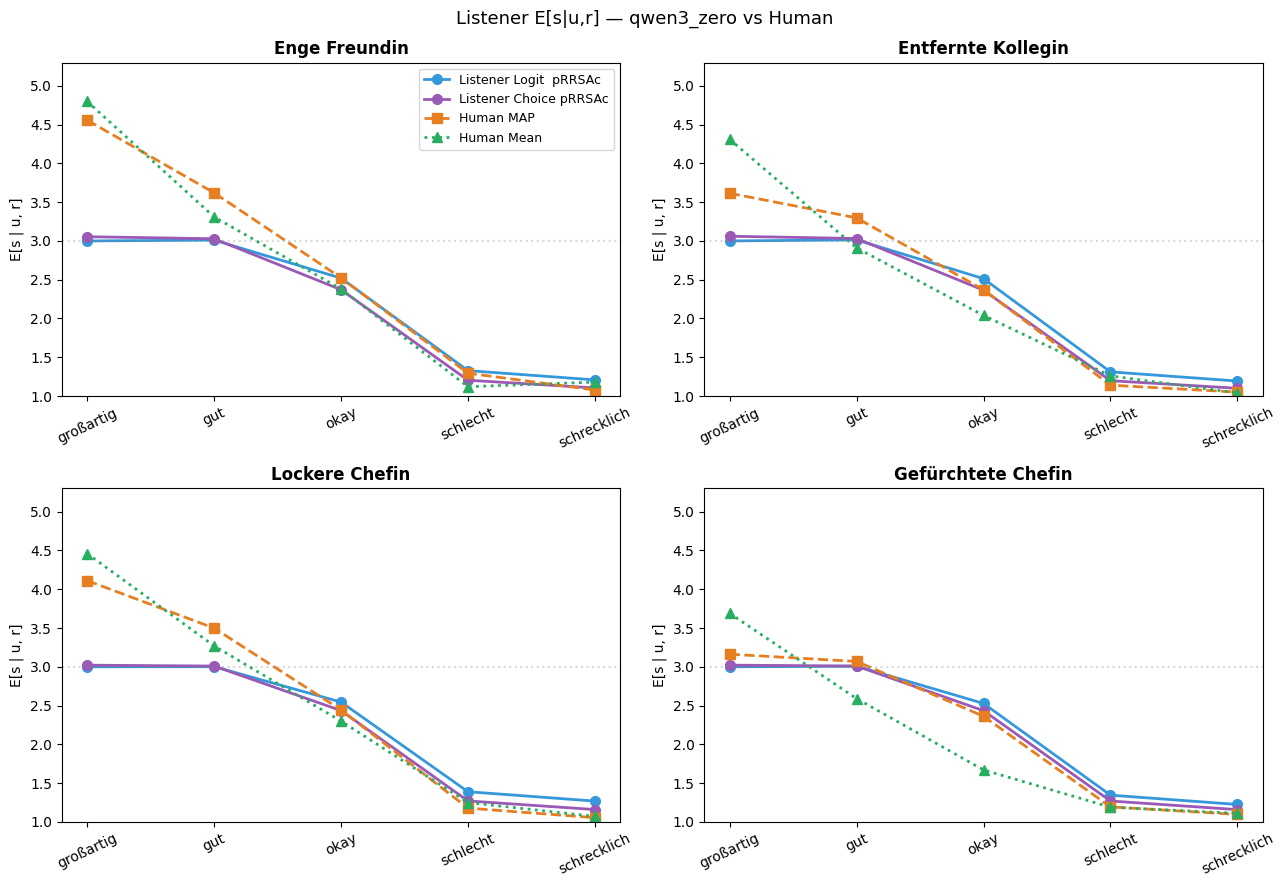

In [33]:
# ── Listener 추론 분포: E[s | u, r] ──────────────────────────────────────────
def compute_L1_np(phi_dict, alpha, lam):
    """pRRSAc numpy 버전: phi_dict = {rel: phi_val}, alpha scalar"""
    L1_all = np.zeros((N_rel, N_utt, N_sta))
    for r_i, rel in enumerate(RELATIONS):
        phi = phi_dict[rel]
        for s_i in range(N_sta):
            u_e = U_epi[:, s_i]
            utility = phi * u_e + (1 - phi) * alpha * U_soc_base
            logits = lam * utility; logits -= logits.max()
            S1_col = np.exp(logits); S1_col /= S1_col.sum()
            L1_all[r_i, :, s_i] = S1_col
        L1_all[r_i] = L1_all[r_i] / L1_all[r_i].sum(axis=1, keepdims=True)
    return L1_all


# TRACES에서 phi 기반 모델(pRRSAc)만 추출
phi_model_traces = {k: tr for k, (tr, param) in TRACES.items()
                    if tr is not None and param == 'phi' and 'phi' in tr.posterior}

if phi_model_traces:
    colors = ['#3498db', '#9b59b6', '#e74c3c', '#1abc9c']
    L1_hum = compute_L1_np(HUMAN_PHI_C, HUMAN_ALPHA_C, HUMAN_LAM)

    fig, axes = plt.subplots(2, 2, figsize=(13, 9))
    for ax, (r_i, rel) in zip(axes.flatten(), enumerate(RELATIONS)):
        e_hum     = (L1_hum[r_i] * state_vals[np.newaxis, :]).sum(1)
        human_exp = [HUMAN_TABLE_ME.get((rel, u), np.nan) for u in UTTERANCES]

        for ci, (key, tr) in enumerate(phi_model_traces.items()):
            summ     = az.summary(tr, var_names=['phi', 'alpha', 'lam'])
            phi_est  = {rel_: summ.loc[f'phi[{i}]', 'mean'] for i, rel_ in enumerate(RELATIONS)}
            alpha_est = summ.loc['alpha', 'mean']
            lam_est  = summ.loc['lam', 'mean']
            L1_est   = compute_L1_np(phi_est, alpha_est, lam_est)
            e_llm    = (L1_est[r_i] * state_vals[np.newaxis, :]).sum(1)
            label    = key.split(': ', 1)[1]
            ax.plot(UTTERANCES, e_llm, 'o-', color=colors[ci], lw=2, ms=7, label=label)

        ax.plot(UTTERANCES, e_hum,     's--', color='#e67e22', lw=2, ms=7, label='Human MAP')
        ax.plot(UTTERANCES, human_exp, '^:',  color='#27ae60', lw=2, ms=7, label='Human Mean')
        ax.set_title(rel, fontweight='bold')
        ax.set_ylim(1, 5.3); ax.set_ylabel('E[s | u, r]')
        ax.tick_params(axis='x', rotation=25); ax.axhline(3, color='gray', ls=':', alpha=0.3)

    axes[0, 0].legend(fontsize=9)
    fig.suptitle(f'Listener E[s|u,r] — {MODEL} vs Human', fontsize=13)
    plt.tight_layout()
    plt.savefig(f'results/listener_inferred_state_{MODEL}.png', dpi=150, bbox_inches='tight')
    plt.show()

---
## Step 9 — Posterior Predictive Check (Model A)

In [ ]:
# ── Posterior Predictive Check (Model A) ──────────────────────────────────────
if trace_A is None or logprobs_li_avg is None:
    print('[skip]')
else:
    lam_s   = trace_A.posterior['lam'].values.flatten()
    phi_s   = trace_A.posterior['phi'].values.reshape(-1, N_rel)
    alpha_s = trace_A.posterior['alpha'].values.flatten()
    n_samp  = min(len(lam_s), 500)

    ppc_rows = []
    for r_i, rel in enumerate(RELATIONS):
        for u_i, utt in enumerate(UTTERANCES):
            probs_obs = np.exp(logprobs_li_avg[r_i, u_i, :])
            probs_obs /= probs_obs.sum()
            for s_i in range(N_sta):
                preds = np.array([
                    rsa_listener_np(u_i, phi=phi_s[j, r_i], alpha=alpha_s[j], lam=lam_s[j])[s_i]
                    for j in range(n_samp)
                ])
                ppc_rows.append({
                    'relationship': rel,
                    'prob_obs':     probs_obs[s_i],
                    'pred_mean':    preds.mean(),
                    'pred_lo':      np.percentile(preds, 3),
                    'pred_hi':      np.percentile(preds, 97),
                })

    df_ppc = pd.DataFrame(ppc_rows)
    colors  = dict(zip(RELATIONS, ['#e74c3c', '#3498db', '#2ecc71', '#e67e22']))
    markers = dict(zip(RELATIONS, ['o', 's', '^', 'D']))

    fig, ax = plt.subplots(figsize=(5, 5))
    for rel in RELATIONS:
        d = df_ppc[df_ppc['relationship'] == rel]
        ax.errorbar(
            d['pred_mean'], d['prob_obs'],
            xerr=[d['pred_mean']-d['pred_lo'], d['pred_hi']-d['pred_mean']],
            fmt=markers[rel], color=colors[rel],
            label=rel.replace(' ', '\n'), alpha=0.65, ms=5, capsize=2, lw=0.8,
        )
    ax.plot([0, 1], [0, 1], 'k--', alpha=0.4)
    ax.set_xlim(0, 1); ax.set_ylim(0, 1); ax.set_aspect('equal')
    r_ppc = np.corrcoef(df_ppc['pred_mean'], df_ppc['prob_obs'])[0, 1]
    ax.set_title(f'PPC — Model A  r={r_ppc:.3f}')
    ax.set_xlabel('RSA P_L1(s|u,r)')
    ax.set_ylabel('LLM P(s|u,r)')
    ax.legend(fontsize=8)
    plt.tight_layout()
    plt.savefig(f'results/listener_ppc_{MODEL}.png', dpi=150)
    plt.show()

This script can be run on rsa_modeling.ipynb %run
필요 변수: TRACES, RELATIONS, MODEL

Usage Example:
  %run analysis_phi_convergence.py
  run_phi_convergence_analysis(TRACES, RELATIONS, MODEL)
φ 수렴 분석 대상 모델 (2개):
  • E: Listener Logit  pRRSAc
  • G: Listener Choice pRRSAc

  수렴 요약 테이블  (mean ± SD  [95% HDI])

  관계: Enge Freundin
    Listener Logit  pRRSAc               0.207 ± 0.073  [0.063, 0.345]
    Listener Choice pRRSAc               0.471 ± 0.124  [0.228, 0.685]

  관계: Entfernte Kollegin
    Listener Logit  pRRSAc               0.215 ± 0.076  [0.063, 0.354]
    Listener Choice pRRSAc               0.480 ± 0.124  [0.229, 0.684]

  관계: Lockere Chefin
    Listener Logit  pRRSAc               0.181 ± 0.065  [0.048, 0.298]
    Listener Choice pRRSAc               0.388 ± 0.117  [0.160, 0.600]

  관계: Gefürchtete Chefin
    Listener Logit  pRRSAc               0.199 ± 0.070  [0.056, 0.326]
    Listener Choice pRRSAc               0.389 ± 0.113  [0.176, 0.606]

  95% HDI 겹침 여부  (✓=겹침 / ✗=안겹

/Users/eyun/llm_pragmatics/analysis_phi_convergence.py:182: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from current font.
  plt.tight_layout()
/Users/eyun/llm_pragmatics/analysis_phi_convergence.py:182: UserWarning: Glyph 47156 (\N{HANGUL SYLLABLE RYEOM}) missing from current font.
  plt.tight_layout()
/Users/eyun/llm_pragmatics/analysis_phi_convergence.py:182: UserWarning: Glyph 48516 (\N{HANGUL SYLLABLE BUN}) missing from current font.
  plt.tight_layout()
/Users/eyun/llm_pragmatics/analysis_phi_convergence.py:182: UserWarning: Glyph 49437 (\N{HANGUL SYLLABLE SEOG}) missing from current font.
  plt.tight_layout()
/Users/eyun/llm_pragmatics/analysis_phi_convergence.py:182: UserWarning: Glyph 52769 (\N{HANGUL SYLLABLE CEUG}) missing from current font.
  plt.tight_layout()
/Users/eyun/llm_pragmatics/analysis_phi_convergence.py:182: UserWarning: Glyph 51221 (\N{HANGUL SYLLABLE JEONG}) missing from current font.
  plt.tight_layout()
/Users/eyun/llm_pragmatics/analysis_phi_c

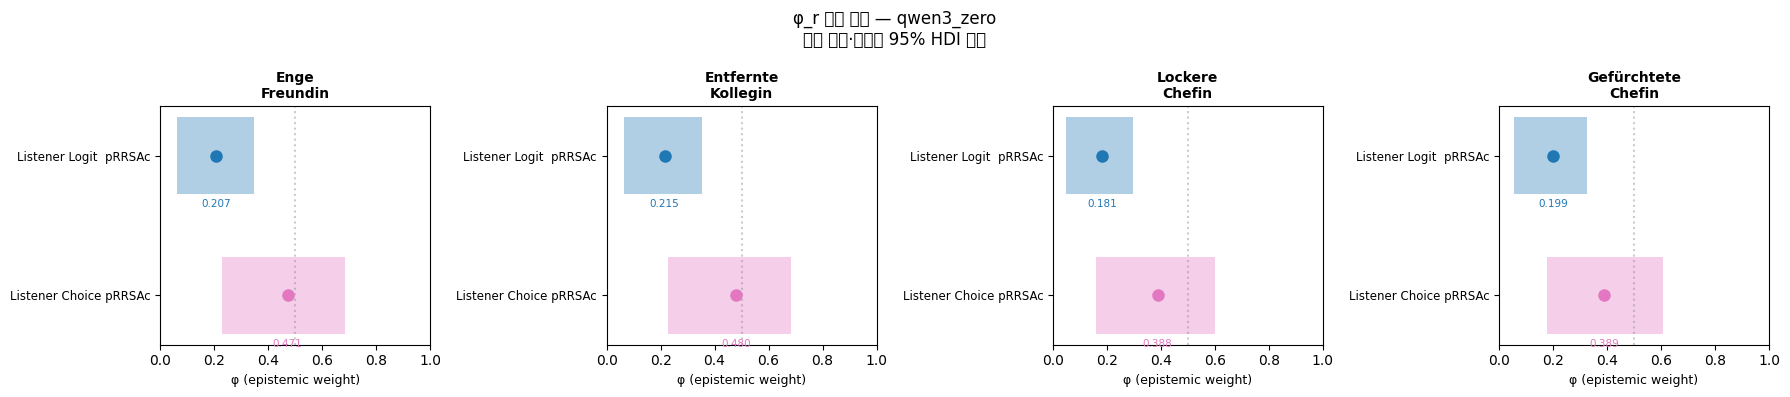

  저장: results/phi_convergence_forest_qwen3_zero.png

  φ_r 패턴 방향성 (관계별 순위  낮을수록 face-saving)
  Listener Logit  pRRSAc
    face-saving ← Lockere Chefin  <  Gefürchtete Chefin  <  Enge Freundin  <  Entfernte Kollegin → epistemic
    순위: Enge Freundi=3  |  Entfernte Ko=4  |  Lockere Chef=1  |  Gefürchtete =2
  Listener Choice pRRSAc
    face-saving ← Lockere Chefin  <  Gefürchtete Chefin  <  Enge Freundin  <  Entfernte Kollegin → epistemic
    순위: Enge Freundi=3  |  Entfernte Ko=4  |  Lockere Chef=1  |  Gefürchtete =2

  자동 결론

  전체 모델 쌍 × 관계 조합: 4개
  HDI 겹침: 4/4 (100%)

  판정: 수렴 (convergent)
  해석: φ_r 추정값이 측정 방법·방향에 무관하게 일관되게 수렴한다.

  관계별 수렴도:
    Enge Freundin             1/1 (100%)  ████████████████████
    Entfernte Kollegin        1/1 (100%)  ████████████████████
    Lockere Chefin            1/1 (100%)  ████████████████████
    Gefürchtete Chefin        1/1 (100%)  ████████████████████


In [35]:
# rsa_modeling.ipynb 하단 셀에 추가
%run analysis_phi_convergence.py
df_summ, df_ov = run_phi_convergence_analysis(TRACES, RELATIONS, MODEL)